In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import keras

import xgboost as xgb
import umap
import shap
import hdbscan

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn import tree
from sklearn.decomposition import PCA
from matplotlib import cm, colors

/opt/anaconda3/envs/SHAP_ADNI/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data Setup

In [2]:
data = pd.read_csv('../../DATA/clean_data.csv', index_col='RID')

In [3]:
data.isnull().sum().sort_values(ascending=False)[0:10]/data.shape[0]

PIB          0.991790
FBB          0.857553
DX_48        0.692939
DIGITSCOR    0.665846
DX_36        0.655172
AV45         0.534893
PTAU         0.501642
ABETA        0.501642
TAU          0.501642
DX_24        0.388342
dtype: float64

In [4]:
X = data.drop(['PTEDUCAT', 'PIB', 'FBB', 'DIGITSCOR', 'AV45', 'PTAU', 'ABETA', 'TAU', 'DX_12', 'DX_24', 'DX_36', 'DX_48'], axis=1)
X_num = X.drop(['PTGENDER', 'PTRACCAT'], axis=1)

In [5]:
def convert_DX_0(x):
    if x == "CN":
        return 0
    elif x == "MCI":
        return 1
    elif x == "Dementia":
        return 2
    else:
        return x

X_num['DX_0'] = X_num['DX_0'].apply(convert_DX_0)
X_final = X_num.drop('DX_0', inplace=False, axis=1)

y = X_num['DX_0']
y = y[-pd.isnull(y)]
X_final = X_final.loc[y.index]

X_final.columns

Index(['AGE', 'APOE4', 'FDG', 'CDRSB', 'ADAS11', 'ADAS13', 'ADASQ4', 'MMSE',
       'RAVLT.immediate', 'RAVLT.learning', 'RAVLT.forgetting',
       'RAVLT.perc.forgetting', 'LDELTOTAL', 'TRABSCOR', 'FAQ', 'MOCA',
       'EcogPtMem', 'EcogPtLang', 'EcogPtVisspat', 'EcogPtPlan', 'EcogPtOrgan',
       'EcogPtDivatt', 'EcogPtTotal', 'EcogSPMem', 'EcogSPLang',
       'EcogSPVisspat', 'EcogSPPlan', 'EcogSPOrgan', 'EcogSPDivatt',
       'EcogSPTotal', 'Ventricles', 'Hippocampus', 'WholeBrain', 'Entorhinal',
       'Fusiform', 'MidTemp', 'ICV', 'mPACCdigit', 'mPACCtrailsB'],
      dtype='object')

In [6]:
scaler = MinMaxScaler()
X_norm = pd.DataFrame(scaler.fit_transform(X_final), columns=X_final.columns, index=X_final.index)

X_no_na = X_norm.dropna()
y_no_na = y[X_no_na.index]

In [7]:
# X_final.to_csv("../../DATA/model comparison/ADNI/adni_clean.csv", index=True)
# X_no_na.to_csv("../../DATA/model comparison/ADNI/adni_no_na.csv", index=True)

# Raw Data

In [8]:
X_umap = umap.UMAP(random_state=2451).fit_transform(X_no_na)

/opt/anaconda3/envs/SHAP_ADNI/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


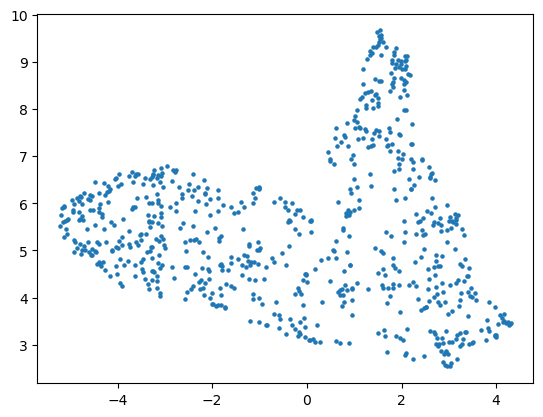

In [9]:
plt.scatter(X_umap[:,0], X_umap[:,1], s=5)

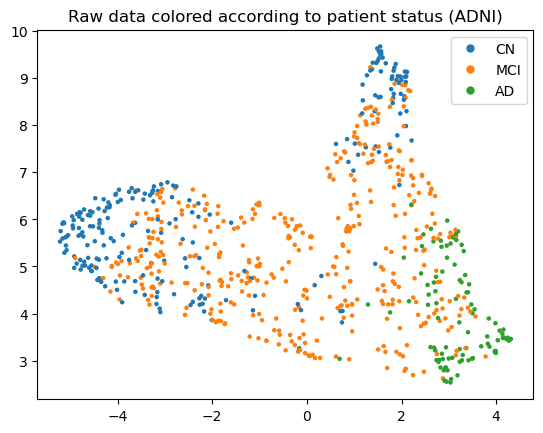

In [10]:
plt.scatter(X_umap[:,0], X_umap[:,1], c=[sns.color_palette()[int(x)] for x in y_no_na], s=5)
plt.title("Raw data colored according to patient status (ADNI)")

labels = ["CN", "MCI", "AD"]
lp = lambda i: plt.plot([],color=sns.color_palette()[i], mec="none",
                        label=labels[i], ls="", marker="o")[0]
handles = [lp(i) for i in range(3)]
plt.legend(handles=handles, loc="best")

# Decision Tree

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.3, random_state=3901)

In [12]:
param_grid = {
    'max_depth': range(1, 10, 1),
    'min_samples_leaf': range(1, 20, 2),
    'min_samples_split': range(2, 20, 2),
    'criterion': ["entropy", "gini"]
}

tree_temp = tree.DecisionTreeClassifier(random_state=9503)

grid_search = GridSearchCV(estimator=tree_temp, param_grid=param_grid, 
                           cv=5, verbose=True)
grid_search.fit(X_train, y_train)

print("best accuracy", grid_search.best_score_)
print(grid_search.best_estimator_)

Fitting 5 folds for each of 1620 candidates, totalling 8100 fits
best accuracy 0.9327433628318584
DecisionTreeClassifier(criterion='entropy', max_depth=4, min_samples_leaf=5,
                       min_samples_split=14, random_state=9503)


In [13]:
# clf = grid_search.best_estimator_

clf = tree.DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, min_samples_split=14, criterion='entropy', random_state=9503)
clf.fit(X_train, y_train)

clf.score(X_test, y_test)
print(classification_report(y_test, clf.predict(X_test)))

              precision    recall  f1-score   support

         0.0       0.99      0.96      0.97       257
         1.0       0.88      0.96      0.92       342
         2.0       0.90      0.73      0.81       128

    accuracy                           0.92       727
   macro avg       0.92      0.88      0.90       727
weighted avg       0.92      0.92      0.92       727



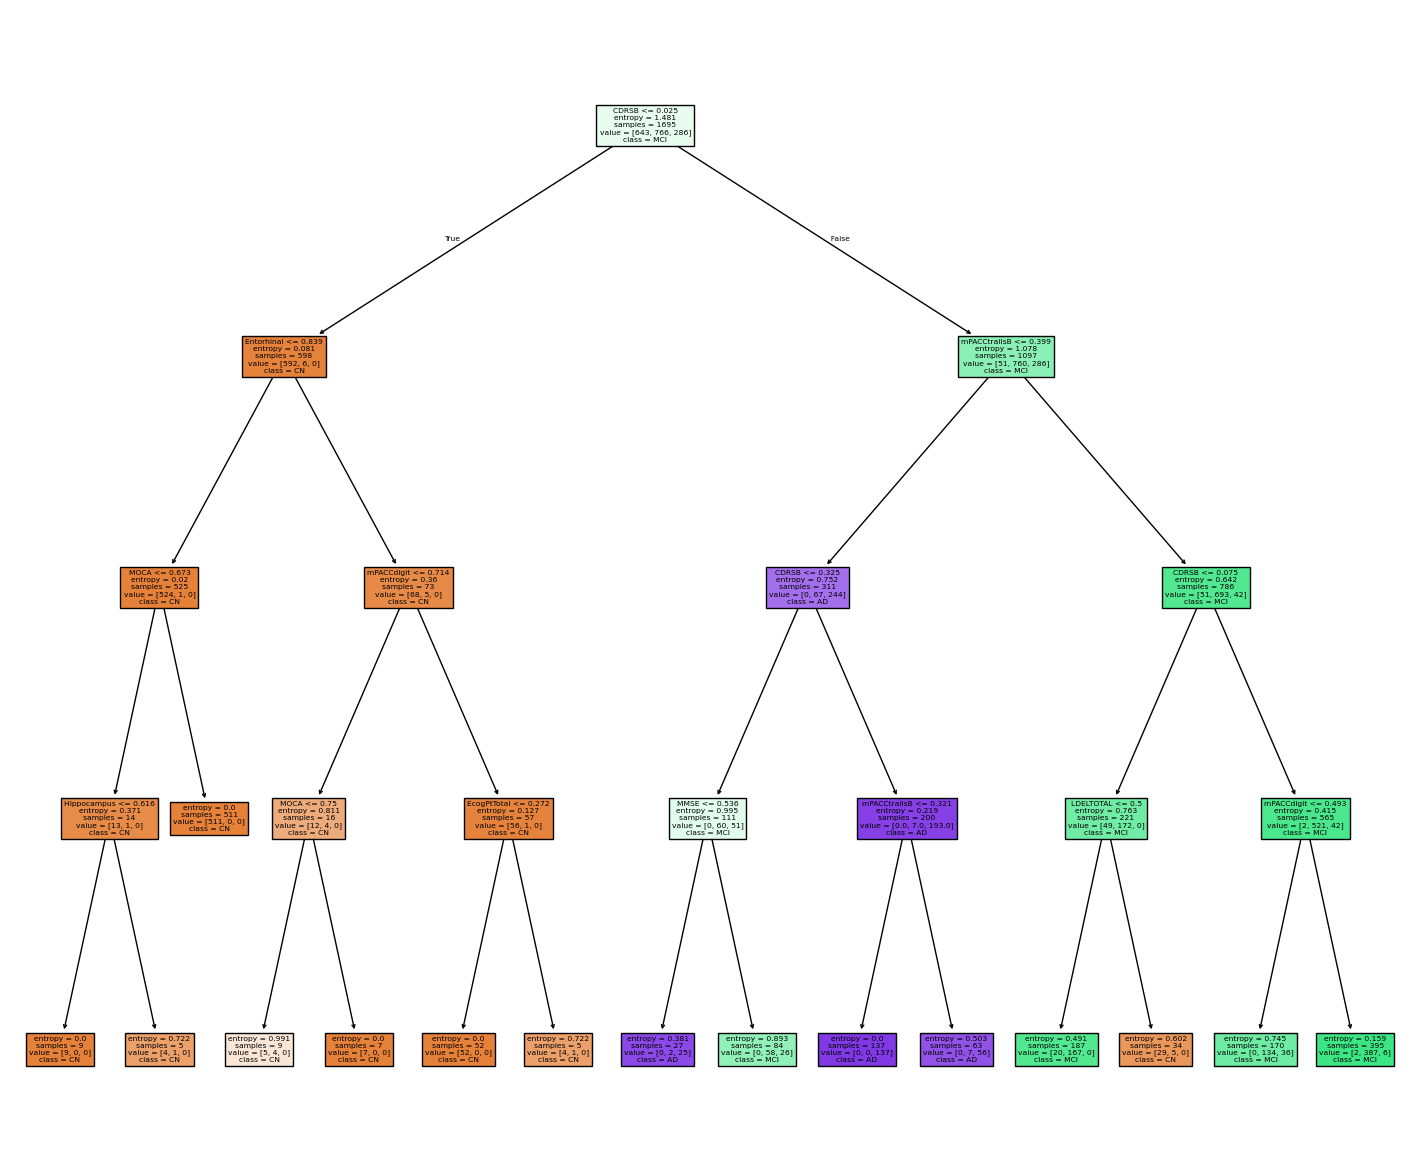

In [14]:
plt.figure(figsize=(18, 15))
tree.plot_tree(clf, filled=True, feature_names=X_norm.columns,
          class_names=['CN','MCI','AD'])
plt.show()

## SHAP

In [15]:
explainer_dt = shap.TreeExplainer(clf)
explanation_dt = explainer_dt(X_norm)

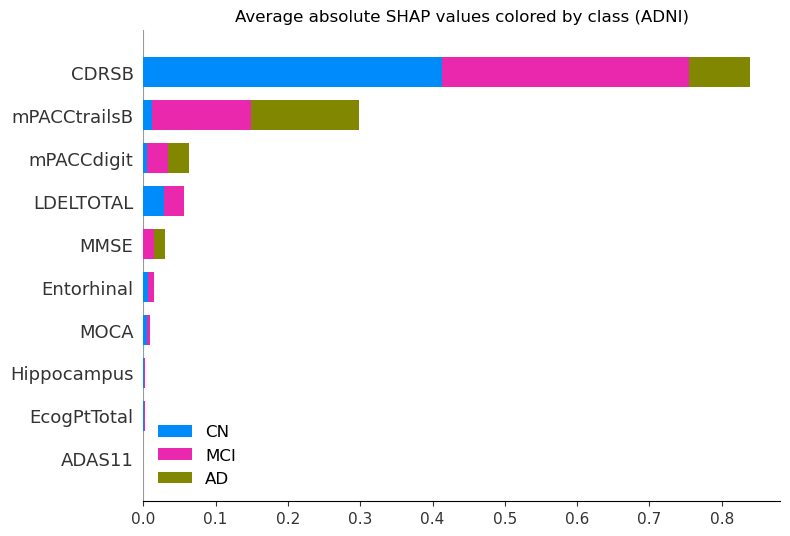

In [16]:
shap.summary_plot(explanation_dt, class_names=['CN','MCI','AD'], max_display=10, class_inds='original', show=False)
f = plt.gcf()
ax = plt.gca()

ax.set_title("Average absolute SHAP values colored by class (ADNI)")
ax.set_xlabel("")
plt.show()

In [17]:
SHAP_flat_dt = pd.DataFrame(np.asarray([explanation_dt.values[i].flatten() for i in range(explanation_dt.values.shape[0])]),
                            columns=np.asarray([X_norm.columns + "_" + condition for condition in ['CN', 'MCI', 'AD']]).flatten('F'))

# SHAP_flat_dt.to_csv("../DATA/model comparison/ADNI/adni_shap_dt.csv", index=False)

/opt/anaconda3/envs/SHAP_ADNI/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


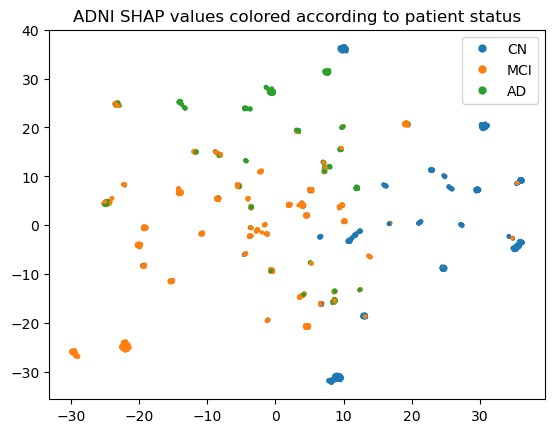

In [18]:
X_umap_SHAP_dt = umap.UMAP(metric='cosine', init='pca', n_neighbors=50, min_dist=0.5, random_state=110).fit_transform(SHAP_flat_dt)

plt.scatter(X_umap_SHAP_dt[:,0], X_umap_SHAP_dt[:,1], c=[sns.color_palette()[int(x)] for x in y], s=5)
plt.title("ADNI SHAP values colored according to patient status")

labels = ["CN", "MCI", "AD"]
lp = lambda i: plt.plot([],color=sns.color_palette()[i], mec="none",
                        label=labels[i], ls="", marker="o")[0]
handles = [lp(i) for i in range(3)]
plt.legend(handles=handles, loc="best")

Text(0.5, 1.0, 'SHAP vectors colored according to terminal node (ADNI)')

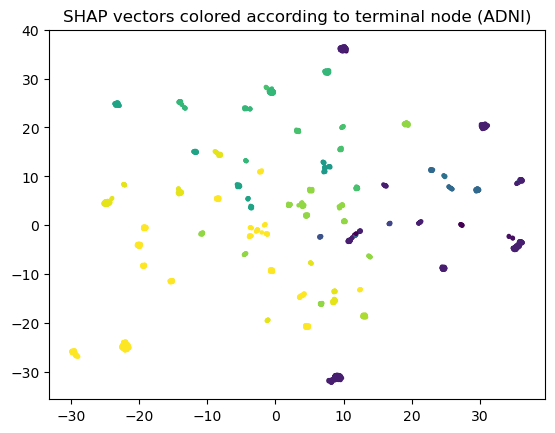

In [19]:
plt.scatter(X_umap_SHAP_dt[:,0], X_umap_SHAP_dt[:,1], c=clf.apply(X_norm), s=5)
plt.title("SHAP vectors colored according to terminal node (ADNI)")

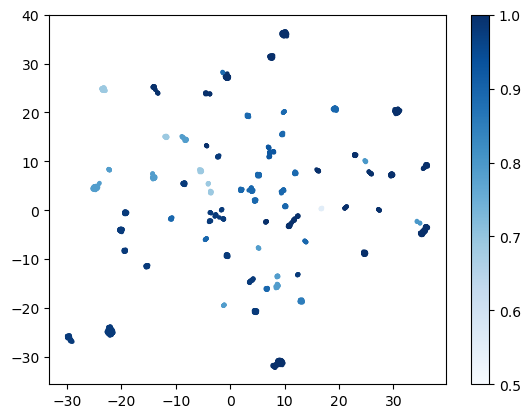

In [20]:
plt.scatter(X_umap_SHAP_dt[:,0], X_umap_SHAP_dt[:,1], c=np.amax(clf.predict_proba(X_norm), axis=1), vmin=0.5, vmax=1, s=5, cmap="Blues")
plt.colorbar()

# XGBoost

In [21]:
param_grid = {
    'min_child_weight': [1, 5, 10],
    'gamma': [0.5, 1, 1.5, 2, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'max_depth': [3, 4, 5]
}

# model_temp = xgb.XGBClassifier(objective='multi:softmax', num_class=3, random_state=29184)

# grid_search = GridSearchCV(estimator=model_temp, param_grid=param_grid, 
#                            cv=5, verbose=True)
# grid_search.fit(X_train, y_train)

# print("best accuracy", grid_search.best_score_)
# print(grid_search.best_estimator_)

In [22]:
# model_xgb = grid_search.best_estimator_

model_xgb = xgb.XGBClassifier(objective='multi:softmax', num_class=3, random_state=29184,
                          min_child_weight=1, gamma=5, subsample=1, colsample_bytree=0.6, max_depth=4)
model_xgb.fit(X_train, y_train)

print(classification_report(y_test, model_xgb.predict(X_test)))

              precision    recall  f1-score   support

         0.0       0.99      0.95      0.97       257
         1.0       0.91      0.96      0.93       342
         2.0       0.90      0.83      0.86       128

    accuracy                           0.93       727
   macro avg       0.93      0.91      0.92       727
weighted avg       0.93      0.93      0.93       727



## SHAP

In [23]:
explainer_xgb = shap.TreeExplainer(model_xgb)
explanation_xgb = explainer_xgb(X_norm)

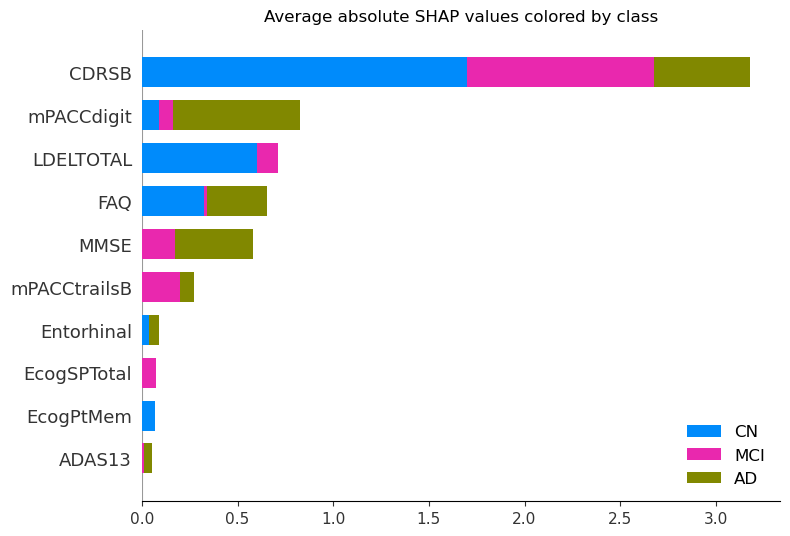

In [24]:
shap.summary_plot(explanation_xgb, class_names=['CN','MCI','AD'], max_display=10, class_inds='original', show=False)
f = plt.gcf()
ax = plt.gca()

ax.set_title("Average absolute SHAP values colored by class")
ax.set_xlabel("")
plt.show()

In [25]:
SHAP_flat_xgb = pd.DataFrame(np.asarray([explanation_xgb.values[i].flatten() for i in range(explanation_xgb.values.shape[0])]),
                         columns=np.asarray([X_norm.columns + "_" + condition for condition in ['CN', 'MCI', 'AD']]).flatten('F'))

# SHAP_flat_xgb.to_csv("../../DATA/model comparison/ADNI/adni_shap_xgb.csv", index=False)

/opt/anaconda3/envs/SHAP_ADNI/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


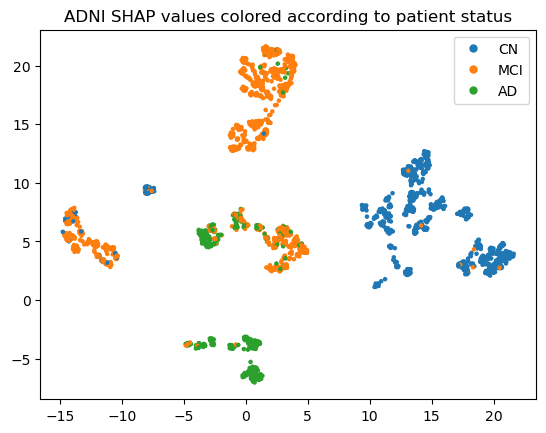

In [26]:
X_umap_SHAP_xgb = umap.UMAP(n_neighbors=80, min_dist=0.5, random_state=29218).fit_transform(SHAP_flat_xgb)

plt.scatter(X_umap_SHAP_xgb[:,0], X_umap_SHAP_xgb[:,1], c=[sns.color_palette()[int(x)] for x in y], s=5)
plt.title("ADNI SHAP values colored according to patient status")

labels = ["CN", "MCI", "AD"]
lp = lambda i: plt.plot([],color=sns.color_palette()[i], mec="none",
                        label=labels[i], ls="", marker="o")[0]
handles = [lp(i) for i in range(3)]
plt.legend(handles=handles, loc="best")

/opt/anaconda3/envs/SHAP_ADNI/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/SHAP_ADNI/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


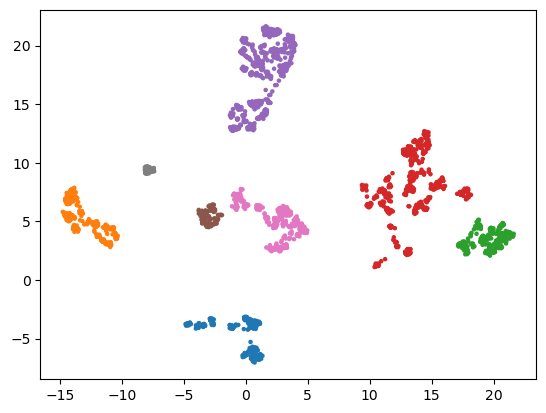

In [27]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=110, min_samples=20)
clusterer.fit(X_umap_SHAP_xgb)

clusterer.labels_[np.where(clusterer.labels_ == -1)] = max(clusterer.labels_) + 1

labels = [f"Cluster {i}" for i in range(max(clusterer.labels_))]
lp = lambda i: ax.plot([],color=sns.color_palette()[i], mec="none",
                        label=labels[i], ls="", marker="o")[0]
handles = [lp(i) for i in range(max(clusterer.labels_))]

plt.scatter(X_umap_SHAP_xgb[:,0], X_umap_SHAP_xgb[:,1], c=[sns.color_palette()[int(x)] for x in clusterer.labels_], s=5)
# plt.legend(handles=handles, loc="best")

In [28]:
# np.savetxt("../../DATA/model comparison/ADNI/adni_hdbscan.csv", clusterer.labels_, delimiter=",", header="cluster")

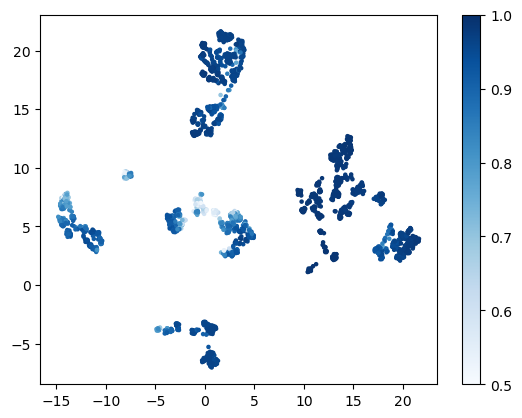

In [29]:
plt.scatter(X_umap_SHAP_xgb[:,0], X_umap_SHAP_xgb[:,1], c=np.amax(model_xgb.predict_proba(X_norm), axis=1), vmin=0.5, vmax=1, s=5, cmap="Blues")
plt.colorbar()

# Neural Network

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X_no_na, y_no_na, test_size=0.3, random_state=1923)

In [31]:
keras.utils.set_random_seed(109)

model_nn = keras.Sequential()
model_nn.add(keras.Input(shape = (X_train.shape[1],)))
model_nn.add(keras.layers.Dense(20, activation = 'relu'))
model_nn.add(keras.layers.Dense(20, activation = 'relu'))
model_nn.add(keras.layers.Dense(3, activation='softmax'))

model_nn.compile(loss="sparse_categorical_crossentropy", optimizer='adam', metrics=['accuracy'])

model_nn.fit(X_train, y_train, epochs=100, shuffle = True)

scores = model_nn.evaluate(X_test, y_test)
print(model_nn.metrics_names[0], model_nn.metrics_names[1])

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6272 - loss: 0.8749 
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5883 - loss: 0.8115
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6350 - loss: 0.7622
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7204 - loss: 0.7180
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7282 - loss: 0.6759
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7301 - loss: 0.6338
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7437 - loss: 0.5962
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7553 - loss: 0.5667
Epoch 9/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7748 - loss: 0.5413
Epoch 10/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7689 - loss: 0.5248
Epoch 11/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8019 - loss: 0.5083
Epoch 12/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy

In [32]:
print(classification_report(y_test, np.argmax(model_nn.predict(X_test), axis = -1)))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

         0.0       0.94      0.93      0.94        71
         1.0       0.93      0.90      0.91       118
         2.0       0.79      0.91      0.85        33

    accuracy                           0.91       222
   macro avg       0.89      0.91      0.90       222
weighted avg       0.91      0.91      0.91       222



## SHAP

In [33]:
# explainer_nn = shap.KernelExplainer(model_nn.predict, shap.kmeans(X_train, k=50))
# explanation_nn = explainer_nn(X_no_na)

# np.savetxt("adni_shap_vals_flat.csv", explanation_nn.values.reshape(737, -1), delimiter=',')
# np.savetxt("adni_base_vals_flat.csv", explanation_nn.base_values.reshape(737, -1), delimiter=',')

In [34]:
vals = np.array(pd.read_csv("adni_shap_vals_flat.csv", header=None)).reshape(737, 39, 3)
base_vals = np.array(pd.read_csv("adni_base_vals_flat.csv", header=None))

explanation_nn = shap.Explanation(values=vals,
                                  feature_names=X_no_na.columns,
                                  base_values=base_vals,
                                  data=X_no_na)

/var/folders/7_/f25wqpvj6qz4hhj2lydnm6cr0000gn/T/ipykernel_9524/3659168293.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(explanation_nn, class_names=['CN','MCI','AD'], max_display=10, class_inds='original', show=False)


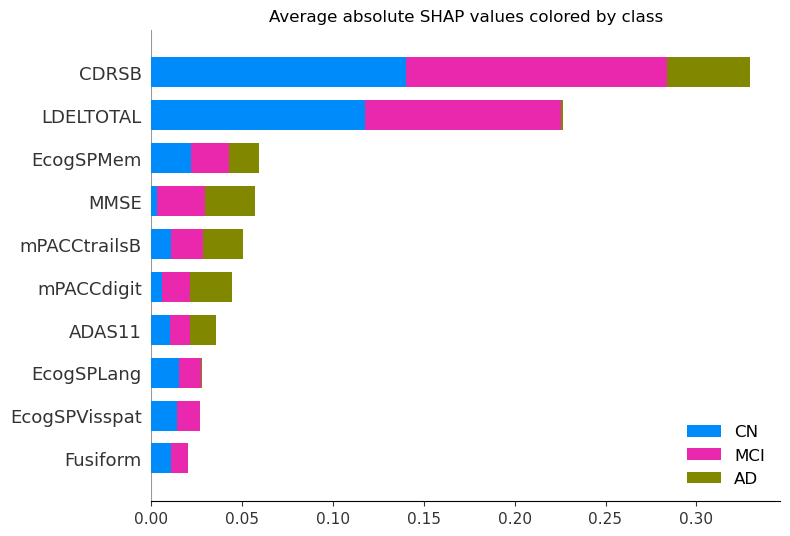

In [35]:
shap.summary_plot(explanation_nn, class_names=['CN','MCI','AD'], max_display=10, class_inds='original', show=False)
f = plt.gcf()
ax = plt.gca()

ax.set_title("Average absolute SHAP values colored by class")
ax.set_xlabel("")
plt.show()

In [36]:
SHAP_flat_nn = pd.DataFrame(np.asarray([explanation_nn.values[i].flatten() for i in range(explanation_nn.values.shape[0])]),
                            columns=np.asarray([X_no_na.columns + "_" + condition for condition in ['CN', 'MCI', 'AD']]).flatten('F'))

# SHAP_flat_nn.to_csv("../../DATA/model comparison/ADNI/adni_shap_nn.csv", index=False)

In [37]:
X_umap_SHAP_nn = umap.UMAP(random_state=29218).fit_transform(SHAP_flat_nn)

/opt/anaconda3/envs/SHAP_ADNI/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


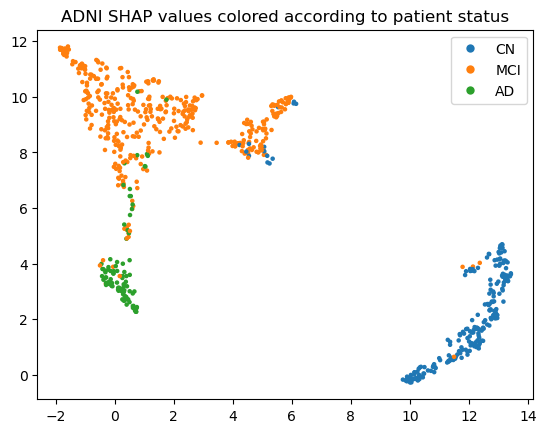

In [38]:
plt.scatter(X_umap_SHAP_nn[:,0], X_umap_SHAP_nn[:,1], c=[sns.color_palette()[int(x)] for x in y_no_na], s=5)
plt.title("ADNI SHAP values colored according to patient status")

labels = ["CN", "MCI", "AD"]
lp = lambda i: plt.plot([],color=sns.color_palette()[i], mec="none",
                        label=labels[i], ls="", marker="o")[0]
handles = [lp(i) for i in range(3)]
plt.legend(handles=handles, loc="best")

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


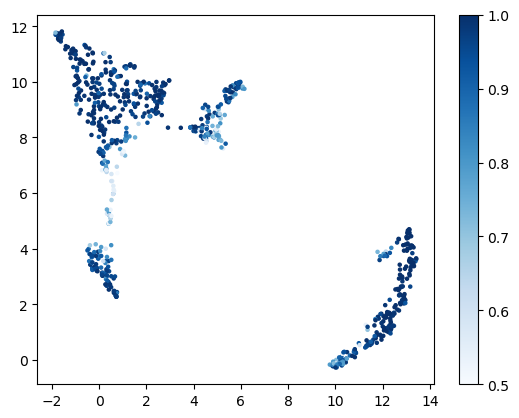

In [39]:
plt.scatter(X_umap_SHAP_nn[:,0], X_umap_SHAP_nn[:,1], c=np.amax(model_nn.predict(X_no_na), axis=1), cmap="Blues", vmin=0.5, vmax=1, s=5)
plt.colorbar()

# Combined

In [40]:
no_na_index = [np.where(np.array(X_norm.index) == x)[0][0] for x in X_no_na.index]

In [41]:
# np.savetxt("../../DATA/model comparison/ADNI/adni_hdbscan_no_na.csv", clusterer.labels_[no_na_index], delimiter=",", header="cluster")

Text(0.5, 1.0, 'Neural Network')

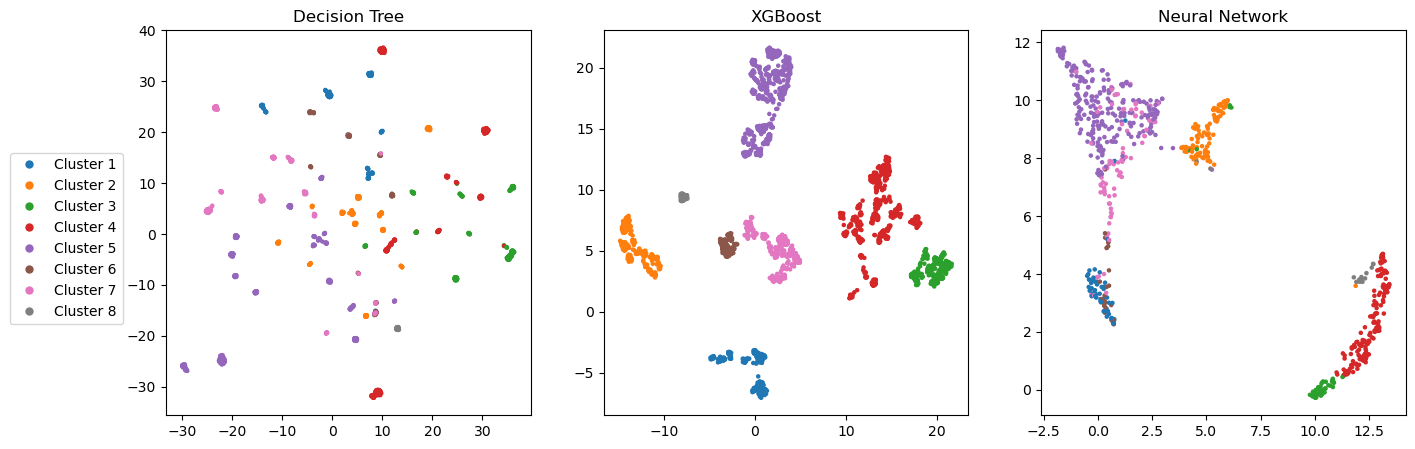

In [42]:
f, (ax1, ax2, ax3) = plt.subplots(1,3)

f.set_size_inches(16, 5)

ax1.scatter(X_umap_SHAP_dt[:,0], X_umap_SHAP_dt[:,1], c=[sns.color_palette()[int(x)] for x in clusterer.labels_], s=5)
ax1.set_title("Decision Tree")

labels = ["Cluster 1", "Cluster 2", "Cluster 3", "Cluster 4", "Cluster 5", "Cluster 6", "Cluster 7", "Cluster 8"]
lp = lambda i: ax1.plot([],color=sns.color_palette()[i], mec="none",
                        label=labels[i], ls="", marker="o")[0]
handles = [lp(i) for i in range(8)]
ax1.legend(handles=handles, bbox_to_anchor=(-0.1, 0.7))

ax2.scatter(X_umap_SHAP_xgb[:,0], X_umap_SHAP_xgb[:,1], c=[sns.color_palette()[int(x)] for x in clusterer.labels_], s=5)
ax2.set_title("XGBoost")

ax3.scatter(X_umap_SHAP_nn[:,0], X_umap_SHAP_nn[:,1], c=[sns.color_palette()[int(x)] for x in clusterer.labels_[no_na_index]], s=5)
ax3.set_title("Neural Network")

Text(0.5, 1.0, 'Neural Network')

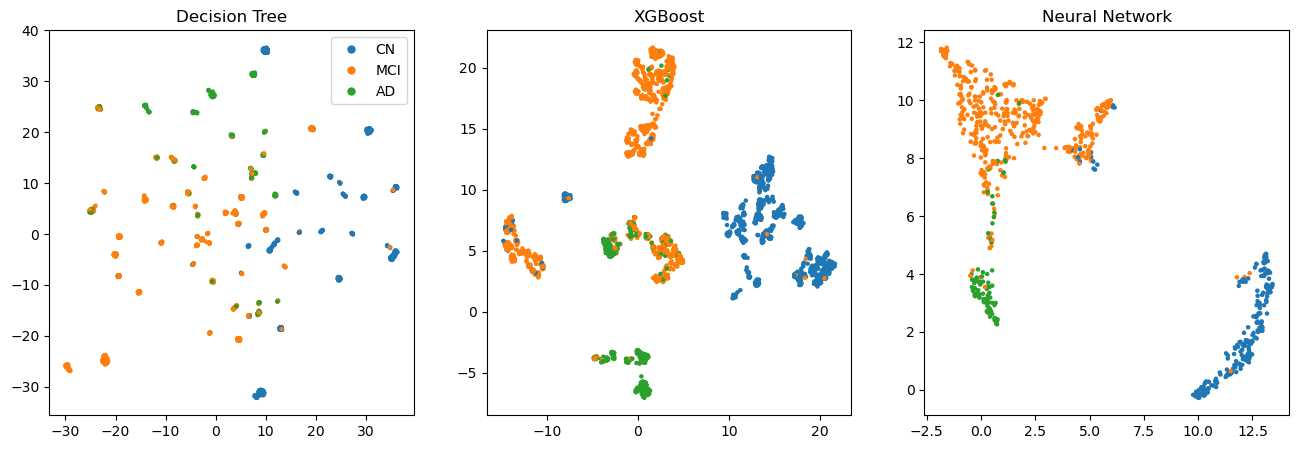

In [43]:
f, (ax1, ax2, ax3) = plt.subplots(1,3)

f.set_size_inches(16, 5)

ax1.scatter(X_umap_SHAP_dt[:,0], X_umap_SHAP_dt[:,1], c=[sns.color_palette()[int(x)] for x in y], s=5)
ax1.set_title("Decision Tree")

labels = ["CN", "MCI", "AD"]
lp = lambda i: ax1.plot([],color=sns.color_palette()[i], mec="none",
                        label=labels[i], ls="", marker="o")[0]
handles = [lp(i) for i in range(3)]
ax1.legend(handles=handles, loc="best")

ax2.scatter(X_umap_SHAP_xgb[:,0], X_umap_SHAP_xgb[:,1], c=[sns.color_palette()[int(x)] for x in y], s=5)
ax2.set_title("XGBoost")

ax3.scatter(X_umap_SHAP_nn[:,0], X_umap_SHAP_nn[:,1], c=[sns.color_palette()[int(x)] for x in y_no_na], s=5)
ax3.set_title("Neural Network")

In [44]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


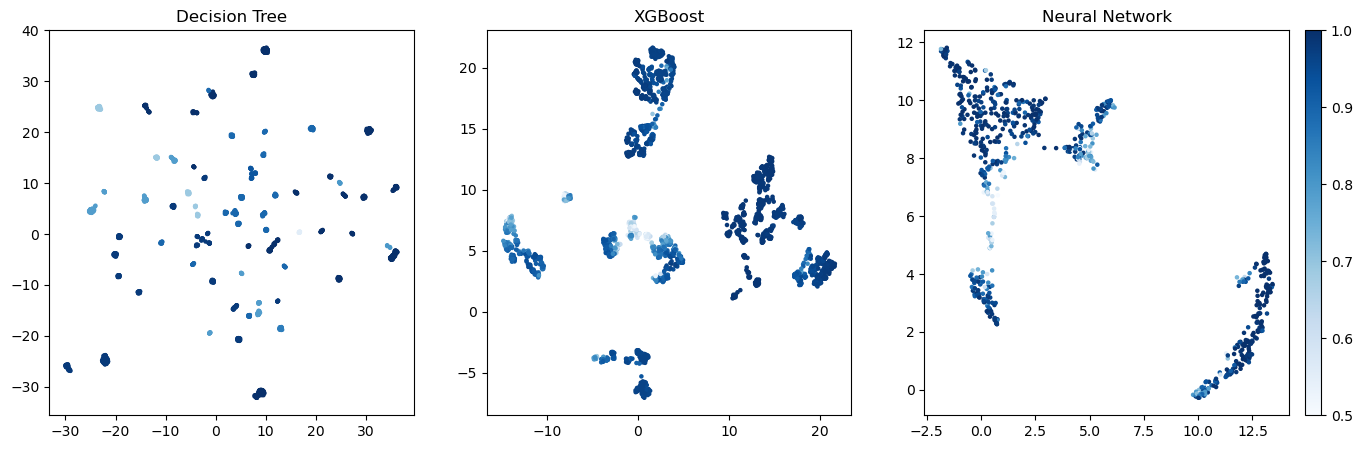

In [45]:
f, (ax1, ax2, ax3) = plt.subplots(1,3)

f.set_size_inches(16, 5)

ax1.scatter(X_umap_SHAP_dt[:,0], X_umap_SHAP_dt[:,1], c=np.amax(clf.predict_proba(X_norm), axis=1), vmin=0.5, vmax=1, cmap="Blues", s=5)
ax1.set_title("Decision Tree")

ax2.scatter(X_umap_SHAP_xgb[:,0], X_umap_SHAP_xgb[:,1], c=np.amax(model_xgb.predict_proba(X_norm), axis=1), vmin=0.5, vmax=1, cmap="Blues", s=5)
ax2.set_title("XGBoost")

ax3.scatter(X_umap_SHAP_nn[:,0], X_umap_SHAP_nn[:,1], c=np.amax(model_nn.predict(X_no_na), axis=1), vmin=0.5, vmax=1, cmap="Blues", s=5)
ax3.set_title("Neural Network")

ax_cbar = f.add_axes([ax3.get_position().get_points()[1,0] + 0.01,
                      ax3.get_position().get_points()[0,1],
                      0.01,
                      ax3.get_position().get_points()[1,1] - ax3.get_position().get_points()[0,1]])


f.colorbar(cm.ScalarMappable(norm=colors.Normalize(0.5, 1), cmap="Blues"), cax=ax_cbar)

In [46]:
raw_heat_df = pd.concat([pd.Series(clusterer.labels_, name="Cluster"), pd.DataFrame(X_final)], axis=1)[['Cluster', 'CDRSB', 'mPACCdigit', 'LDELTOTAL', 'FAQ', 'MMSE']].groupby('Cluster').mean()

Text(0.5, 1.0, 'Heatmap of top features across clusters (ADNI)')

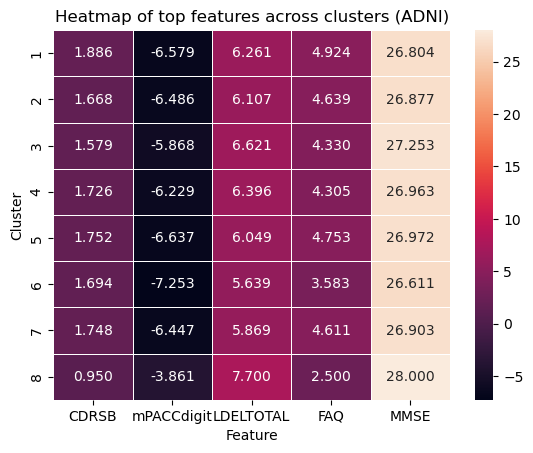

In [47]:
f, ax = plt.subplots()

sns.heatmap(raw_heat_df, yticklabels=['1', '2', '3', '4', '5', '6', '7', '8'], annot=True, linewidth=0.5, fmt=".3f", ax=ax)
ax.set(xlabel = "Feature", ylabel="Cluster")
ax.set_title("Heatmap of top features across clusters (ADNI)")